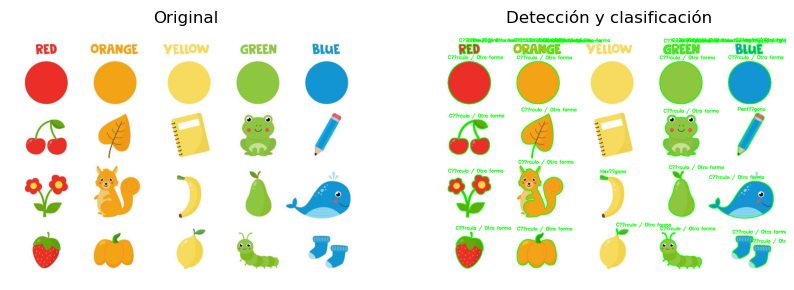

[{'clasificacion': 'Círculo / Otra forma', 'vertices': 8, 'area': 4595, 'hu_moments': [0.7216090978696262, 2.2157734620326854, 3.6157353058227284, 5.38613571002499, -9.956084423511781, 7.52536607070488, -10.153151656131175]}, {'clasificacion': 'Círculo / Otra forma', 'vertices': 8, 'area': 4582, 'hu_moments': [0.721466553384407, 2.212170926783735, 3.6129805129746932, 5.427444407526973, -10.019135077611951, 7.497968309036287, -10.205397919868869]}, {'clasificacion': 'Círculo / Otra forma', 'vertices': 12, 'area': 14554, 'hu_moments': [0.7570657905380181, 2.522539752198752, 3.8690614332963524, 6.042227499794817, -11.006965825707264, -7.3835303468383415, 11.238270132663208]}, {'clasificacion': 'Círculo / Otra forma', 'vertices': 11, 'area': 9104, 'hu_moments': [0.519150316549118, 1.3627968933877206, 2.059470716688027, 2.8497522307048624, 6.841923537821708, -4.278509668252385, 5.3045463479437585]}, {'clasificacion': 'Círculo / Otra forma', 'vertices': 10, 'area': 10348, 'hu_moments': [0.78

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def clasificar_por_vertices(approx):
    vertices = len(approx)
    if vertices == 3:
        return "Triángulo"
    elif vertices == 4:
        return "Cuadrado / Rectángulo"
    elif vertices == 5:
        return "Pentágono"
    elif vertices == 6:
        return "Hexágono"
    else:
        return "Círculo / Otra forma"

def detectar_figuras_y_momentos(ruta_imagen):
    img = cv2.imread(ruta_imagen)
    if img is None:
        raise FileNotFoundError(f"No se encontró la imagen: {ruta_imagen}")

    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binaria = cv2.threshold(gris, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    contornos, _ = cv2.findContours(binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    salida = img.copy()
    resultados = []

    for contorno in contornos:
        area = cv2.contourArea(contorno)
        if area < 200:  # ignora pequeños ruidos
            continue

        perimetro = cv2.arcLength(contorno, True)
        approx = cv2.approxPolyDP(contorno, 0.02 * perimetro, True)
        clasificacion = clasificar_por_vertices(approx)

        momentos = cv2.moments(contorno)
        hu = cv2.HuMoments(momentos).flatten()
        hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-12)

        cv2.drawContours(salida, [contorno], -1, (0, 255, 0), 2)
        x, y, w, h = cv2.boundingRect(contorno)
        cv2.putText(salida, clasificacion, (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        resultados.append({
            "clasificacion": clasificacion,
            "vertices": len(approx),
            "area": int(area),
            "hu_moments": hu_log.tolist()
        })

    plt.figure(figsize=(10, 6))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Detección y clasificación")
    plt.imshow(cv2.cvtColor(salida, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    return resultados


resultados = detectar_figuras_y_momentos("colores.jpg")
print(resultados)